# NLP4RE - Testing
Este notebook permite visualizar qué está pasando por debajo del sistema: Base de datos, Embeddings, Chunks, y el proceso de RAG.


## 1. Configuración Inicial
Cargamos las variables de entorno y verificamos la conexión a la base de datos.


In [21]:
import os
import sys
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
import requests

#add back path to import models
sys.path.append('../backend')

load_dotenv('../.env')

API_URL = "http://localhost:8000"

print(f"Postgres Host: {os.getenv('POSTGRES_HOST')}")
print(f"LLM Provider: {os.getenv('LLM_PROVIDER')}")

#test api conection
try:
    response = requests.get(f"{API_URL}/health")
    print("API Health:", response.json())
except Exception as e:
    print("Error conectando a la API. Asegúrate de que los contenedores estén corriendo.")


Postgres Host: localhost
LLM Provider: None
API Health: {'api': 'ok', 'database': 'ok', 'llm_provider': 'local'}


## 2. Ingesta de Datos (Preparación)
Vamos a subir los PDFs que tienes en la carpeta `data/raw` para asegurar que tenemos datos con los qué trabajar. Si ya los subiste con `test.http`, puedes saltar esta celda.


In [22]:
import time

pdfs_to_upload = [
    '../data/raw/req-agendate.pdf', 
    '../data/raw/req-ride-now.pdf', 
    '../data/raw/req-seminario.pdf',
    '../data/raw/iso_29148.pdf',
]

for pdf_path in pdfs_to_upload:
    if os.path.exists(pdf_path):
        print(f"Subiendo {os.path.basename(pdf_path)}...")
        with open(pdf_path, 'rb') as f:
            files = {'file': (os.path.basename(pdf_path), f, 'application/pdf')}
            try:
                res = requests.post(f"{API_URL}/upload/pdf", files=files)
                print(f"Resultado: {res.status_code}")
                if res.status_code == 200:
                    print(res.json().get('message', ''))
                else:
                    print(res.json())
            except Exception as e:
                print(f"Error subiendo: {e}")
    else:
        print(f"Archivo no encontrado: {pdf_path}")
    time.sleep(1)


Subiendo req-agendate.pdf...
Resultado: 200
PDF procesado exitosamente. Se extrajeron 11 chunks y se indexaron 43 requisitos.
Subiendo req-ride-now.pdf...
Resultado: 200
PDF procesado exitosamente. Se extrajeron 14 chunks y se indexaron 70 requisitos.
Subiendo req-seminario.pdf...
Resultado: 200
PDF procesado exitosamente. Se extrajeron 57 chunks y se indexaron 57 requisitos.
Subiendo iso_29148.pdf...
Resultado: 200
PDF procesado exitosamente. Se extrajeron 405 chunks y se indexaron 972 requisitos.


## 3. Inspección de la Base de Datos
Vamos a conectarnos directamente a la base de datos para ver qué guardó el sistema.


In [23]:
# db conection
db_url = f"postgresql://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}/{os.getenv('POSTGRES_DB')}"
engine = create_engine(db_url)

with engine.connect() as conn:
    # count requirements
    req_count = conn.execute(text("SELECT COUNT(*) FROM requirements")).scalar()
    print(f"Total de requisitos en BD: {req_count}")
    
    # count chunks by doc
    doc_count = conn.execute(text("SELECT COUNT(*) FROM documents")).scalar()
    print(f"Total de chunks (documentos) en BD: {doc_count}")


Total de requisitos en BD: 1142
Total de chunks (documentos) en BD: 487


### 3.1. Viendo los Requisitos Guardados
Extraemos una muestra de los requerimientos para ver cómo los procesó y limpió el sistema antes de guardarlos.


In [24]:
query = "SELECT id, source_name, text, created_at FROM requirements LIMIT 5"
df_reqs = pd.read_sql(query, engine)
pd.set_option('display.max_colwidth', 150)
display(df_reqs)


,id,source_name,text,created_at
0,bba54c41-cf25-41f8-b59b-24e939c8790d,req-agendate.pdf,Requerimientos funcionales,2026-05-11 18:58:49.873643+00:00
1,be7ce8aa-25da-4d81-9f4f-7ba5dbe24c74,req-agendate.pdf,"RF-01 - Crear cita\nEl cliente podrá reservar una cita seleccionando servicio, proveedor, fecha y franja horaria.\nCriterio de aceptación: reserva...",2026-05-11 18:58:49.873712+00:00
2,8ff8910d-f71c-4bf1-bfdd-267013ea778a,req-agendate.pdf,"RF-02 - Consultar disponibilidad\nLa interfaz muestra la disponibilidad real del proveedor considerando plan de trabajo,\ndescansos, bloqueos y re...",2026-05-11 18:58:49.873749+00:00
3,288f8daa-34c7-4ff1-899e-fe6d3b0236b7,req-agendate.pdf,"RF-03 - Validación de reglas y conflictos\nToda petición de reserva pasa por validaciones: bloqueo por conflicto, mínimo tiempo de\nantelación, ve...",2026-05-11 18:58:49.873754+00:00
4,1efbf30b-ca54-489e-9dd1-d2479e269004,req-agendate.pdf,RF-04 - Reprogramar cita,2026-05-11 18:58:49.873758+00:00


### 3.2. Viendo los Chunks del Contexto Normativo
Verificamos los fragmentos de la ISO 29148. Notaremos cómo el texto fue dividido y almacenado.


In [25]:
query_docs = "SELECT id, source, page, chunk_index, content FROM documents LIMIT 5"
df_docs = pd.read_sql(query_docs, engine)
display(df_docs)


,id,source,page,chunk_index,content
0,7f148583-3efc-4576-bfbc-e8bf262d9eea,req-agendate.pdf,0,0,"Requerimientos funcionales\nRF-01 — Crear cita\nEl cliente podrá reservar una cita seleccionando servicio, proveedor, fecha y franja horaria.\nCri..."
1,90bc06c7-a997-40fc-b2a1-07e21e9b000c,req-agendate.pdf,0,1,"reglas se aplican uniformemente en UI y API.\nRF-04 — Reprogramar cita\nCliente, proveedor o administrador pueden cambiar fecha/hora/proveedor/ser..."
2,5d3eb8f7-c684-4e8a-af24-593b92cf71e3,req-agendate.pdf,0,2,"Proveedor/administrador pueden ver calendarios en vistas diaria, semanal y mensual; citas\ncodificadas por color; filtros por servicio/proveedor/e..."
3,5d2aa0aa-6c4f-4b12-a1c5-efa82a3f7e7c,req-agendate.pdf,1,3,"RF-08 — Crear plan de disponibilidad\nProveedor o administrador pueden registrar un plan de trabajo indicando días, horarios y\nreglas de atención..."
4,59397083-cb8c-4356-af0b-88d5cdde7563,req-agendate.pdf,1,4,"RF-09 — Gestión de servicios\nAdministrador puede crear/leer/actualizar/eliminar servicios (nombre, duración, precio,\ncategoría).\nCriterio de ac..."


## 4. Inspección de los Embeddings
La magia del RAG (Retrieval-Augmented Generation) ocurre gracias a los embeddings (vectores). Extraigamos los vectores para ver su dimensionalidad e inspeccionar cómo representan el texto.


In [26]:
# Vamos a extraer los embeddings. pgvector los almacena en un formato array.
# Convertiremos el string de vector '[0.1, 0.2, ...]' a una lista de Python
import numpy as np
import ast

query_emb = "SELECT id, text, embedding::text FROM requirements LIMIT 10"
df_embs = pd.read_sql(query_emb, engine)

# Convertir el string de vector a numpy array
df_embs['embedding'] = df_embs['embedding'].apply(lambda x: np.array(ast.literal_eval(x)) if x else None)

# Mostrar la dimensión del primer embedding
if not df_embs.empty and df_embs['embedding'].iloc[0] is not None:
    dim = len(df_embs['embedding'].iloc[0])
    print(f"Dimensionalidad de los embeddings: {dim} (Debería ser 768 para Gemini embedding-001 o 1536 para text-embedding-3-small)")
else:
    print("No hay embeddings para mostrar.")


Dimensionalidad de los embeddings: 768 (Debería ser 768 para Gemini embedding-001 o 1536 para text-embedding-3-small)


### 4.1. Visualización de los Embeddings (PCA)
Vamos a reducir la dimensionalidad a 2 dimensiones usando PCA para ver cómo se agrupan los requisitos en el espacio vectorial según su documento de origen.


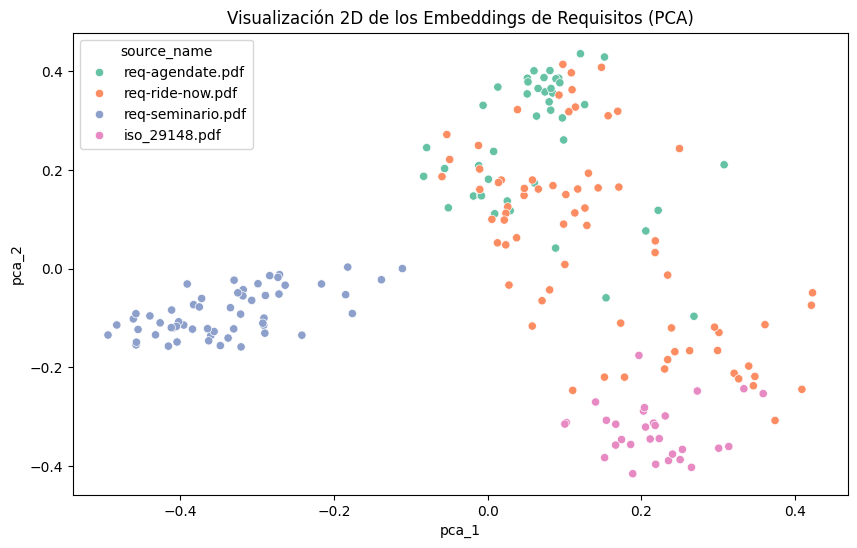

In [27]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

# Traer más requisitos con sus vectores y origen
query_plot = "SELECT source_name, embedding::text FROM requirements WHERE embedding IS NOT NULL LIMIT 200"
df_plot = pd.read_sql(query_plot, engine)

if not df_plot.empty:
    df_plot['embedding'] = df_plot['embedding'].apply(lambda x: np.array(ast.literal_eval(x)))
    X = np.stack(df_plot['embedding'].values)
    
    # Reducción a 2D
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    df_plot['pca_1'] = X_pca[:, 0]
    df_plot['pca_2'] = X_pca[:, 1]
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_plot, x='pca_1', y='pca_2', hue='source_name', palette='Set2')
    plt.title('Visualización 2D de los Embeddings de Requisitos (PCA)')
    plt.show()
else:
    print("No hay suficientes datos para visualizar.")


## 5. Pruebas del Retriever (Similitud del Coseno)
Vamos a ver cómo pgvector recupera los chunks más relevantes para un requerimiento dado. Esto es clave porque el LLM usará este contexto para evaluar.


In [28]:
# Definimos un requerimiento de prueba
req_test = "El sistema debe tener un login seguro"

# Le pedimos al retriever que busque los 3 chunks normativos más similares
try:
    res = requests.post(f"{API_URL}/analyze", json={"text": req_test})
    if res.status_code == 200:
        data = res.json()
        print(f"Requerimiento: {req_test}\n")
        print("CONTEXTO RECUPERADO (TOP 3 CHUNKS):")
        print("-" * 50)
        for i, context in enumerate(data.get('context_used', [])):
            print(f"Chunk {i+1}:")
            # Imprimimos los primeros 300 caracteres del chunk
            print(context[:300] + "...")
            print("-" * 50)
except Exception as e:
    print(f"Error: {e}")


Requerimiento: El sistema debe tener un login seguro

CONTEXTO RECUPERADO (TOP 3 CHUNKS):
--------------------------------------------------
Chunk 1:
13. El sistema debe permitir reasignar un radicado de entrada o PQRS a otro usuario
del sistema, conforme un árbol de jerarquía.
14. El sistema debe permitir incluir los radicados de entrada, salida, internos y PQRS
generados desde el mismo sistema.
15. El sistema debe contar con un buscador de expe...
--------------------------------------------------
Chunk 2:
17. El sistema debe permitir el escaneo distribuido: permitir que los usuarios remotos
puedan importar documentos al sistema por escaneo directo mediante la web a
través de un escáner de escritorio compatible para bajos volúmenes.
18. El sistema debe permitir a usuarios con privilegios el reemplazo ...
--------------------------------------------------
Chunk 3:
31. El sistema debe almacenar el histórico de movimientos del expediente y los
usuarios que efectúan el ingreso y modifica

## 6. Pruebas End-to-End: Evaluación y Feedback
Finalmente, analizamos los resultados de la evaluación del LLM y las sugerencias que devuelve el sistema.


In [29]:
import json

if 'data' in locals() and data:
    print("EVALUACIÓN DEL LLM (ISO 29148):")
    print(json.dumps(data.get('evaluation', {}), indent=2, ensure_ascii=False))
    
    print("\n")
    print("FEEDBACK GENERADO:")
    print("Sugerencias:")
    for sug in data.get('feedback', {}).get('suggestions', []):
        print(f"- {sug}")
    print(f"\nRequerimiento Mejorado: {data.get('feedback', {}).get('improved_requirement')}")


EVALUACIÓN DEL LLM (ISO 29148):
{
  "VERIFIABILITY": {
    "score": 1,
    "explanation": "El requerimiento 'login seguro' puede ser verificado mediante pruebas de seguridad y validación de mecanismos de autenticación."
  },
  "ATOMICITY": {
    "score": 0,
    "explanation": "El requerimiento es demasiado amplio; necesita descomponerse en requisitos más específicos sobre autenticación, autorización, etc."
  },
  "AMBIGUITY": {
    "score": 1,
    "explanation": "No especifica los métodos de seguridad a implementar (ej: autenticación multifactorial, políticas de contraseñas)."
  },
  "COMPLETENESS": {
    "score": 0,
    "explanation": "Falta detalle sobre los aspectos que conforman un 'login seguro' (ej: protección contra ataques, gestión de sesiones)."
  },
  "TRACEABLE": {
    "score": 1,
    "explanation": "Podría ser rastreado a requisitos relacionados con la seguridad del sistema y el acceso al usuario."
  }
}


FEEDBACK GENERADO:
Sugerencias:
- Para mejorar la VERIFIABILITY (sco